# Etape 1 : Chargement & exploration des audios

{'belly_pain': 16, 'burping': 8, 'discomfort': 27, 'hungry': 382, 'tired': 24}


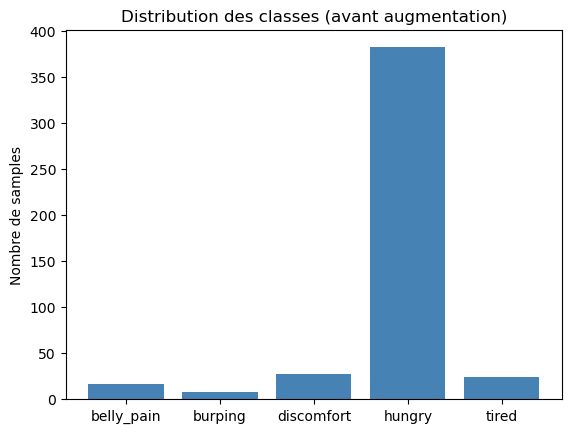

In [3]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import Counter


DATA_DIR = "../data/"
classes = os.listdir(DATA_DIR)

# Vérifier le déséquilibre
counts = {cls: len(os.listdir(f"{DATA_DIR}/{cls}")) for cls in classes}
print(counts)
# Ex: {'hungry': 384, 'burping': 59, 'belly_pain': 101, 'discomfort': 175, 'tired': 409}

# Visualiser la distribution
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title("Distribution des classes (avant augmentation)")
plt.ylabel("Nombre de samples")
plt.show()

# ÉTAPE 2 : Génération des spectrogrammes (3 types)

In [4]:
import librosa
import numpy as np

SR = 16000       # Sample rate
DURATION = 7     # secondes
N_MELS = 128     # bins Mel
HOP_LENGTH = 512
N_FFT = 2048

def load_audio(path, sr=SR, duration=DURATION):
    y, _ = librosa.load(path, sr=sr, duration=duration)
    # Padding si l'audio est trop court
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y[:target_len]

def audio_to_melspectrogram(y, sr=SR):
    """Mel-spectrogramme → format image (H, W, 1)"""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # en dB
    # Normaliser entre 0 et 1
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
    return mel_norm  # shape: (128, T)

# ÉTAPE 3 : Augmentation audio AVANT conversion en spectrogramme

In [5]:
import random

def augment_audio(y, sr=SR):
    """Applique aléatoirement une technique d'augmentation"""
    augmentations = []

    # 1. Time Stretching (ralentir/accélérer)
    rate = random.uniform(0.8, 1.2)
    augmentations.append(librosa.effects.time_stretch(y, rate=rate))

    # 2. Pitch Shifting (changer la tonalité)
    n_steps = random.randint(-3, 3)
    augmentations.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps))

    # 3. Ajout de bruit gaussien
    noise = np.random.normal(0, 0.005, len(y))
    augmentations.append(y + noise)

    # 4. Time Shifting (décalage temporel)
    shift = random.randint(sr//4, sr//2)
    augmentations.append(np.roll(y, shift))

    # 5. Volume perturbation
    factor = random.uniform(0.7, 1.3)
    augmentations.append(y * factor)

    # Retourner une augmentation au hasard
    aug = random.choice(augmentations)
    
    # S'assurer de la même longueur
    target_len = sr * DURATION
    if len(aug) < target_len:
        aug = np.pad(aug, (0, target_len - len(aug)))
    return aug[:target_len]

SpecAugment (augmentation sur le spectrogramme lui-même)

In [6]:
import torch

def spec_augment(mel_spec, freq_mask_param=20, time_mask_param=40, num_masks=2):
    """Masquage de bandes fréquentielles et temporelles"""
    spec = mel_spec.copy()
    
    for _ in range(num_masks):
        # Masque fréquentiel
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, spec.shape[0] - f)
        spec[f0:f0+f, :] = 0
        
        # Masque temporel
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, spec.shape[1] - t)
        spec[:, t0:t0+t] = 0
    
    return spec

# ÉTAPE 4 : Équilibrage des classes (stratégie ciblée)

In [7]:
from collections import Counter

def build_balanced_dataset(data_dir, target_count=None):
    """
    Construit un dataset équilibré en augmentant les classes minoritaires.
    target_count : nombre cible par classe (défaut = max existant)
    """
    all_specs = []
    all_labels = []
    
    # Compter les samples par classe
    class_counts = {cls: len(os.listdir(f"{data_dir}/{cls}")) 
                    for cls in os.listdir(data_dir)}
    
    if target_count is None:
        target_count = max(class_counts.values())
    
    print(f" Cible par classe : {target_count} samples")
    
    for cls_idx, cls_name in enumerate(sorted(class_counts.keys())):
        files = list(Path(f"{data_dir}/{cls_name}").glob("*.wav"))
        current_count = len(files)
        needed = target_count - current_count
        
        print(f"  [{cls_name}] : {current_count} → +{needed} augmentations")
        
        # Ajouter les originaux
        for f in files:
            y = load_audio(str(f))
            mel = audio_to_melspectrogram(y)
            mel = spec_augment(mel)  # SpecAugment sur les originaux aussi
            all_specs.append(mel)
            all_labels.append(cls_idx)
        
        # Augmenter pour atteindre target_count
        for i in range(needed):
            src_file = random.choice(files)
            y = load_audio(str(src_file))
            y_aug = augment_audio(y)
            mel = audio_to_melspectrogram(y_aug)
            mel = spec_augment(mel)
            all_specs.append(mel)
            all_labels.append(cls_idx)
    
    return np.array(all_specs), np.array(all_labels)

X, y = build_balanced_dataset(DATA_DIR)
print(f"\n Dataset final : {X.shape}, labels : {Counter(y)}")
# Toutes les classes ont le même nombre de samples

 Cible par classe : 382 samples
  [belly_pain] : 16 → +366 augmentations
  [burping] : 8 → +374 augmentations
  [discomfort] : 27 → +355 augmentations
  [hungry] : 382 → +0 augmentations
  [tired] : 24 → +358 augmentations

 Dataset final : (1910, 128, 219), labels : Counter({np.int64(0): 382, np.int64(1): 382, np.int64(2): 382, np.int64(3): 382, np.int64(4): 382})


# ÉTAPE 5 : Vérification visuelle des spectrogrammes

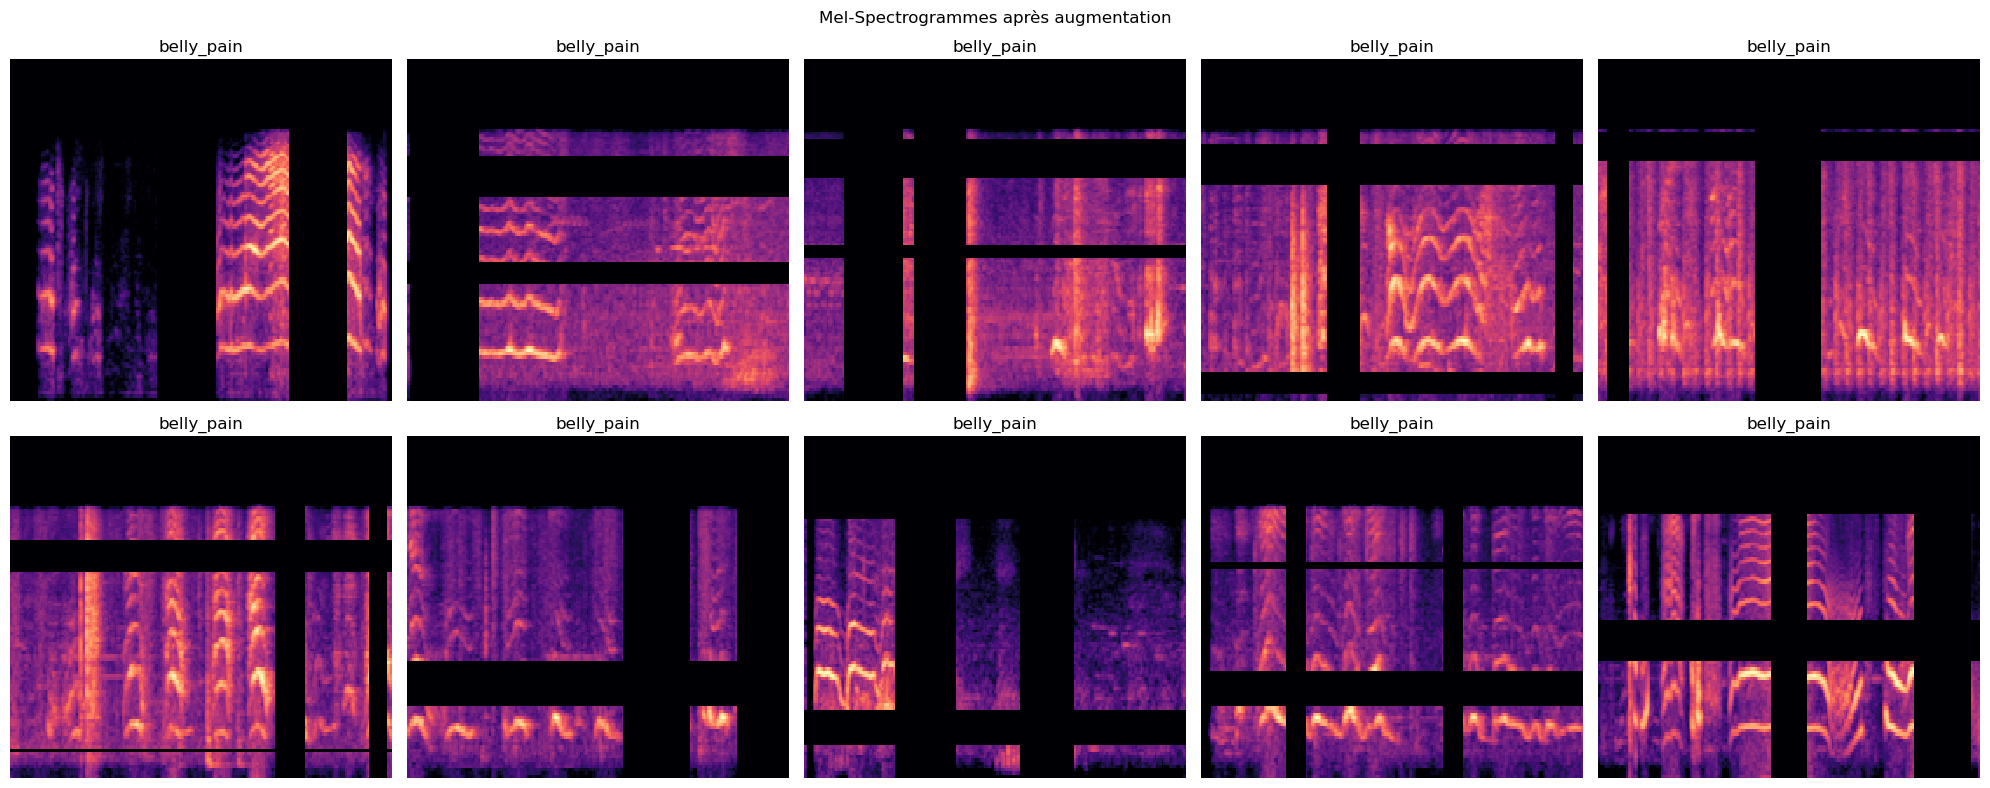

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
class_names = sorted(os.listdir(DATA_DIR))

for i, (spec, label) in enumerate(zip(X[:10], y[:10])):
    ax = axes[i//5][i%5]
    librosa.display.specshow(spec, ax=ax, x_axis='time', y_axis='mel')
    ax.set_title(class_names[label])
    ax.axis('off')

plt.suptitle("Mel-Spectrogrammes après augmentation")
plt.tight_layout()
plt.show()

# ÉTAPE 6 : Préparation pour PyTorch (DataLoader)

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class BabyCryDataset(Dataset):
    def __init__(self, specs, labels, transform=None):
        # specs shape: (N, H, W) → on ajoute un canal: (N, 1, H, W)
        self.specs = torch.FloatTensor(specs).unsqueeze(1)
        self.labels = torch.LongTensor(labels)
        self.transform = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = self.specs[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.labels[idx]

# Split stratifié APRÈS l'équilibrage
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

train_ds = BabyCryDataset(X_train, y_train)
val_ds   = BabyCryDataset(X_val, y_val)
test_ds  = BabyCryDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1337 | Val: 286 | Test: 287


In [13]:
import pickle
import os

os.makedirs('saved_data', exist_ok=True)

# Sauvegarde des DataLoaders + métadonnées (sans la classe personnalisée)
data_to_save = {
    'X_train': X_train,
    'y_train': y_train,
    'X_val':   X_val,
    'y_val':   y_val,
    'X_test':  X_test,
    'y_test':  y_test,
    'class_names': class_names,
}

with open('saved_data/preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("💾 Données prétraitées sauvegardées avec succès !")

💾 Données prétraitées sauvegardées avec succès !
